In [1]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [2]:
wine=load_wine()

In [3]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine.data, wine.target, test_size=0.5, random_state=1)

In [5]:
! pip install scikit-learn gmdhpy

In [6]:
! pip install heamy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for heamy: filename=heamy-0.0.7-py2.py3-none-any.whl size=15451 sha256=be16a4a14525922597905f102110e8587443b43aca760f17ed22c86ae51a8795
  Stored in directory: c:\users\masha\appdata\local\pip\cache\wheels\41\74\9e\7de16119f9f020598e7042847cef7c754bce91ac424a63440d
Successfully built heamy


In [8]:
import inspect
import sys

if not hasattr(inspect, 'getargspec'):
    # Добавляем псевдоним getfullargspec как getargspec
    inspect.getargspec = inspect.getfullargspec
from heamy.estimator import Regressor, Classifier
from heamy.pipeline import ModelsPipeline
from heamy.dataset import Dataset

In [9]:
# Качество отдельных моделей
def val_mae(model):
    model.fit(wine_X_train, wine_y_train)
    y_pred = model.predict(wine_X_test)
    result = mean_absolute_error(wine_y_test, y_pred)
    print(model)
    print('MAE={}'.format(result))

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# Точность на отдельных моделях
for model in [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(n_estimators=50)
]:
    val_mae(model)
    print('==========================')
    print()

LinearRegression()
MAE=0.23201284251888044

DecisionTreeRegressor()
MAE=0.056179775280898875

RandomForestRegressor(n_estimators=50)
MAE=0.08853932584269664



In [14]:
# Используем библиотеку heamy
# набор данных
dataset = Dataset(wine_X_train, wine_y_train, wine_X_test)

# модели первого уровня
model_tree = Regressor(dataset=dataset, estimator=DecisionTreeRegressor, name='tree')
model_lr = Regressor(dataset=dataset, estimator=LinearRegression, parameters={'normalize': True},name='lr')
model_rf = Regressor(dataset=dataset, estimator=RandomForestRegressor, parameters={'n_estimators': 50},name='rf')

In [16]:
from sklearn.preprocessing import StandardScaler

# Нормализуем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(wine_X_train)
X_test_scaled = scaler.transform(wine_X_test)

# Создаём датасет с нормализованными данными
dataset_scaled = Dataset(X_train_scaled, wine_y_train, X_test_scaled)

# Модели с нормализованными данными
model_tree = Regressor(dataset=dataset_scaled, estimator=DecisionTreeRegressor, name='tree')
model_lr = Regressor(dataset=dataset_scaled, estimator=LinearRegression, name='lr')
model_rf = Regressor(dataset=dataset_scaled, estimator=RandomForestRegressor, 
                     parameters={'n_estimators': 50}, name='rf')

In [17]:
# Эксперимент 1
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: линейная регрессия

pipeline = ModelsPipeline(model_tree, model_lr)
stack_ds = pipeline.stack(k=10, seed=1)
# модель второго уровня
stacker = Regressor(dataset=stack_ds, estimator=LinearRegression)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.11732770112647938, 0.13296130328503422, 0.2215136457646759, 0.08353422594160735, 0.11226709695892834, 0.294444304899772, 0.15345339209628558, 0.11939076065704685, 0.15320603010322925, 0.14891255894284772]
Mean accuracy: 0.15370110197759063
Standard Deviation: 0.05831033972612621
Variance: 0.0034000957189762523


In [18]:
# Эксперимент 2
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: случайный лес

stacker = Regressor(dataset=stack_ds, estimator=RandomForestRegressor)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.05666666666666667, 0.09000000000000001, 0.24444444444444446, 0.027777777777777776, 0.07222222222222224, 0.34555555555555556, 0.1111111111111111, 0.08000000000000002, 0.16000000000000003, 0.13374999999999998]
Mean accuracy: 0.13215277777777779
Standard Deviation: 0.09167969709574689
Variance: 0.0084051668595679


In [19]:
# Эксперимент 3
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: линейная регрессия
pipeline = ModelsPipeline(model_tree, model_lr, model_rf)
stack_ds3 = pipeline.stack(k=10, seed=1)
# модель второго уровня
stacker = Regressor(dataset=stack_ds3, estimator=LinearRegression)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.09650131916339921, 0.1360597276271731, 0.17769279157535378, 0.10216697103383242, 0.06912545814680567, 0.2587550903772956, 0.1270510521422431, 0.16043882600101023, 0.12755795710741077, 0.08393993393844235]
Mean accuracy: 0.13392891271129664
Standard Deviation: 0.052345098204352875
Variance: 0.0027400093060233463


In [20]:
# Эксперимент 4
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: случайный лес
# Результат хуже чем в эксперименте 3
stacker = Regressor(dataset=stack_ds3, estimator=RandomForestRegressor)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.06666666666666665, 0.10666666666666669, 0.24888888888888885, 0.016666666666666666, 0.03000000000000001, 0.20666666666666667, 0.10222222222222221, 0.11333333333333334, 0.15888888888888889, 0.06625]
Mean accuracy: 0.111625
Standard Deviation: 0.07069932994470052
Variance: 0.004998395254629627


In [26]:
# Результаты 
array_labels = ['LR', 'TREE', 'RF', 'TREE+LR=>LR', 
                'TREE+LR=>RF', 'TREE+LR+RF=>LR', 'TREE+LR+RF=>RF']
array_mae = [0.2320, 0.0562, 0.0885, 
             0.1537, 0.1322, 0.1339, 0.1116]

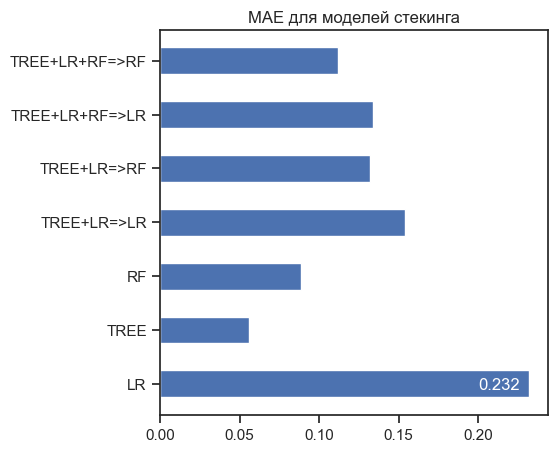

In [27]:
def vis_models_quality(array_metric, array_labels, str_header, figsize=(5, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)
    pos = np.arange(len(array_metric))
    rects = ax1.barh(pos, array_metric,
                     align='center',
                     height=0.5, 
                     tick_label=array_labels)
    ax1.set_title(str_header)
    for a,b in zip(pos, array_metric):
        plt.text(0.2, a-0.1, str(round(b,3)), color='white')
    plt.show()
# Визуализация результатов
vis_models_quality(array_mae, array_labels, 'MAE для моделей стекинга')

In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Масштабирование для MLP (уже сделано в ячейке 16)
# X_train_scaled, X_test_scaled уже существуют

# MLP с разными архитектурами
mlp_models = {
    'MLP (50 нейронов)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42, early_stopping=True),
    'MLP (100,50)': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True),
    'MLP (100,50,25)': MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=500, random_state=42, early_stopping=True)
}

print("="*50)
print("ОБУЧЕНИЕ МНОГОСЛОЙНОГО ПЕРСЕПТРОНА (MLP)")
print("="*50)

mlp_results = {}
for name, mlp in mlp_models.items():
    mlp.fit(X_train_scaled, wine_y_train)
    y_pred = mlp.predict(X_test_scaled)
    acc = accuracy_score(wine_y_test, y_pred)
    mlp_results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# Лучшая MLP модель
best_mlp_name = max(mlp_results, key=mlp_results.get)
best_mlp_acc = mlp_results[best_mlp_name]
print(f"\nЛучшая MLP модель: {best_mlp_name} (Accuracy = {best_mlp_acc:.4f})")

ОБУЧЕНИЕ МНОГОСЛОЙНОГО ПЕРСЕПТРОНА (MLP)
MLP (50 нейронов): Accuracy = 0.8764
MLP (100,50): Accuracy = 0.8427
MLP (100,50,25): Accuracy = 0.9663

Лучшая MLP модель: MLP (100,50,25) (Accuracy = 0.9663)
